In [392]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from transforms3d.quaternions import quat2mat
from scipy.signal import butter, filtfilt, resample

plt.rcParams["figure.figsize"] = (12, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

# ------------------------------------------------------------
# LOAD DATA
# ------------------------------------------------------------

data_dir = Path("/home/nebu/Documents/TUM/Masterarbeit/MasterTheses/logs/Circle/12mps_line")

def load_series(filename, col):
    df = pd.read_csv(data_dir / filename)
    return df[["elapsed time", "value"]].rename(columns={"elapsed time":"t", "value":col})

ax = load_series("linear_acceleration_x.csv", "ax_b")
ay = load_series("linear_acceleration_y.csv", "ay_b")
az = load_series("linear_acceleration_z.csv", "az_b")

qx = load_series("pos_orientation_x.csv", "qx_w")
qy = load_series("pos_orientation_y.csv", "qy_w")
qz = load_series("pos_orientation_z.csv", "qz_w")
qw = load_series("pos_orientation_w.csv", "qw_w")

vx = load_series("twist_linear_x.csv", "vx_w")
vy = load_series("twist_linear_y.csv", "vy_w")
vz = load_series("twist_linear_z.csv", "vz_w")

rpm = load_series("average_motor_speed.csv", "rpm")
rpm["rpm"] *= 10

dfs = [ax, ay, az, qx, qy, qz, qw, vx, vy, vz, rpm]
df = dfs[0]
for d in dfs[1:]:
    df = pd.merge(df, d, on="t", how="outer")
df = df.sort_values("t").interpolate().reset_index(drop=True)

# Fill any remaining NaN values (critical for filtering!)
df = df.fillna(method='ffill').fillna(method='bfill')

print(f"Merged dataframe: {len(df)} samples")

# ------------------------------------------------------------
# RESAMPLE to reasonable rate (100 Hz) WITHOUT interpolation smoothing
# ------------------------------------------------------------
target_dt = 0.01  # 100 Hz
t_uniform = np.arange(df["t"].min(), df["t"].max(), target_dt)

# Find nearest neighbor instead of interpolation to preserve noise
df_uniform = pd.DataFrame({"t": t_uniform})
for col in df.columns:
    if col != "t":
        # Use nearest neighbor to avoid smoothing
        indices = np.searchsorted(df["t"], t_uniform)
        indices = np.clip(indices, 0, len(df)-1)
        df_uniform[col] = df[col].iloc[indices].values

df = df_uniform.copy()
print(f"Resampled to {len(df)} samples at ~{1/target_dt:.0f} Hz (nearest neighbor)")

# ------------------------------------------------------------
# FILTERING
# ------------------------------------------------------------

t = df["t"].to_numpy()
dt = np.median(np.diff(t))
fs = 1/dt
print(f"dt ~ {dt*1e3:.1f} ms, fs ~ {fs:.1f} Hz")

def lowpass(x, fc, order=2):
    """Low-pass filter with NaN handling"""
    # Ensure input is array and has no NaN
    x_arr = np.array(x)
    if np.isnan(x_arr).any():
        print(f"Warning: NaN detected in signal, filter may fail")
        return x_arr
    
    nyq = 0.5*fs
    wn = fc/nyq
    if wn >= 1.0:
        print(f"Warning: cutoff {fc} Hz >= Nyquist {nyq} Hz, skipping filter")
        return x_arr
    b,a = butter(order, wn, btype="low")
    return filtfilt(b, a, x_arr)

cut_acc = 5
cut_vel = 3  
cut_rpm = 2
cut_quat = 3  # quaternion/orientation

df["ax_b_f"] = lowpass(df["ax_b"], cut_acc)
df["ay_b_f"] = lowpass(df["ay_b"], cut_acc)
df["az_b_f"] = lowpass(df["az_b"], cut_acc)

df["vx_w_f"] = lowpass(df["vx_w"], cut_vel)
df["vy_w_f"] = lowpass(df["vy_w"], cut_vel)
df["vz_w_f"] = lowpass(df["vz_w"], cut_vel)

df["rpm_f"] = lowpass(df["rpm"], cut_rpm)

# Filter quaternions (orientation)
df["qw_w_f"] = lowpass(df["qw_w"], cut_quat)
df["qx_w_f"] = lowpass(df["qx_w"], cut_quat)
df["qy_w_f"] = lowpass(df["qy_w"], cut_quat)
df["qz_w_f"] = lowpass(df["qz_w"], cut_quat)

# Normalize filtered quaternions (important!)
for i in range(len(df)):
    q_norm = np.sqrt(df.loc[i, "qw_w_f"]**2 + df.loc[i, "qx_w_f"]**2 + 
                     df.loc[i, "qy_w_f"]**2 + df.loc[i, "qz_w_f"]**2)
    df.loc[i, "qw_w_f"] /= q_norm
    df.loc[i, "qx_w_f"] /= q_norm
    df.loc[i, "qy_w_f"] /= q_norm
    df.loc[i, "qz_w_f"] /= q_norm

# ------------------------------------------------------------
# ROTATION HELPER FUNCTION
# ------------------------------------------------------------

def R_wb(qw, qx, qy, qz):
    """world -> body rotation"""
    R_bw = quat2mat([qw, qx, qy, qz])  # body -> world
    return R_bw.T

# ------------------------------------------------------------
# PLOT HELPER FUNCTION
# ------------------------------------------------------------

def plot_raw_filt(raw, filt, name, unit):
    """Plot raw vs filtered signals"""
    t_plot = df["t"].to_numpy()
    plt.figure(figsize=(12,3))
    plt.plot(t_plot, raw, alpha=0.6, label="raw", linewidth=0.8)
    plt.plot(t_plot, filt, linewidth=2.5, label="filtered", color='orange')
    plt.title(name)
    plt.ylabel(unit)
    plt.xlabel("Time [s]")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

/tmp/ipykernel_2879543/3231281773.py:45: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill').fillna(method='bfill')


Merged dataframe: 23584 samples
Resampled to 912 samples at ~100 Hz (nearest neighbor)
dt ~ 10.0 ms, fs ~ 100.0 Hz


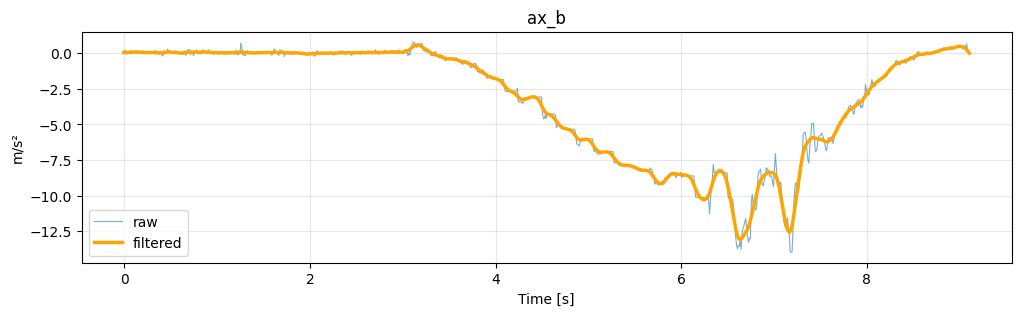

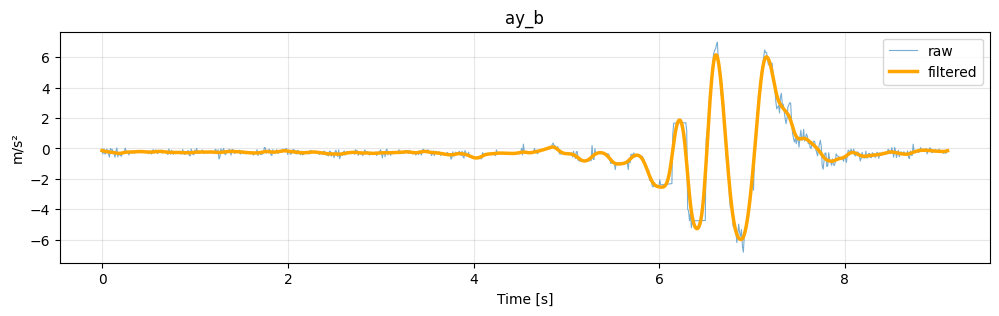

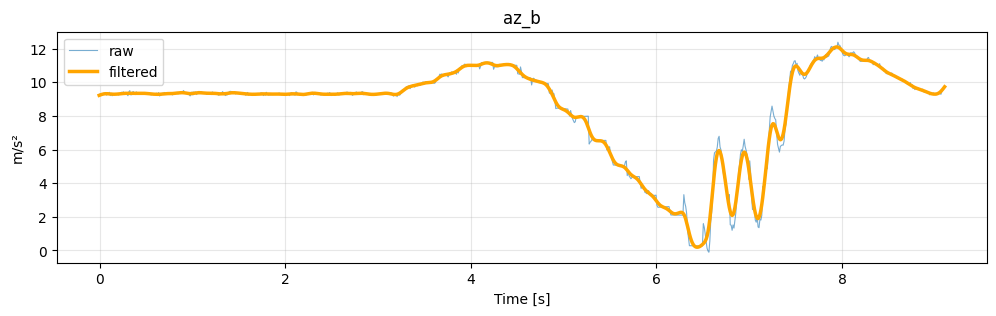

In [393]:
# ------------------------------------------------------------
# DIAGNOSTIC PLOTS: Accelerations (raw vs filtered)
# ------------------------------------------------------------

plot_raw_filt(df["ax_b"], df["ax_b_f"], "ax_b", "m/s²")
plot_raw_filt(df["ay_b"], df["ay_b_f"], "ay_b", "m/s²")
plot_raw_filt(df["az_b"], df["az_b_f"], "az_b", "m/s²")

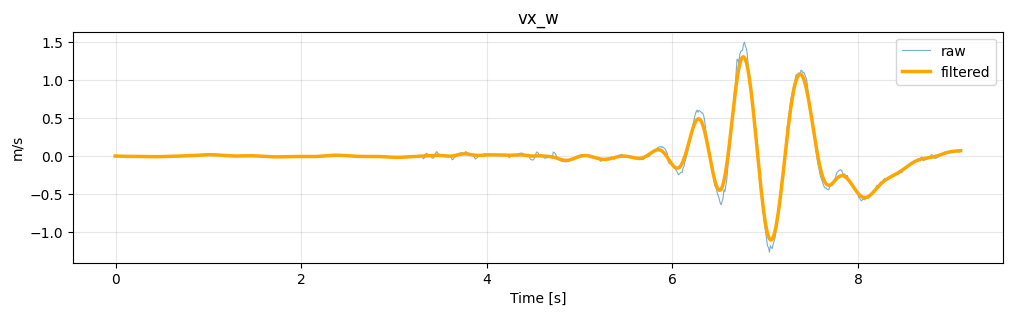

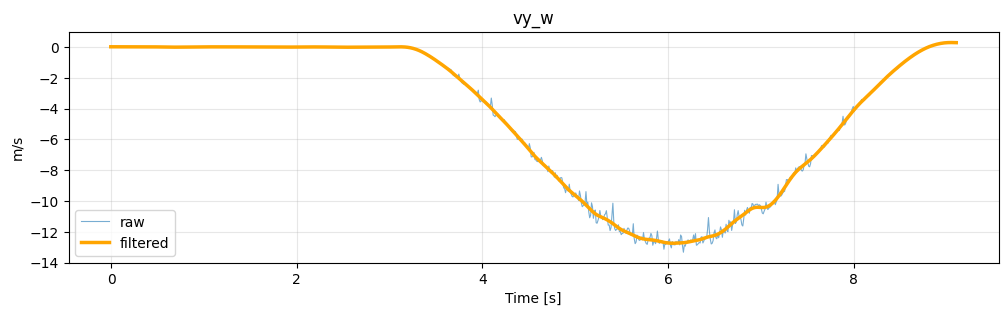

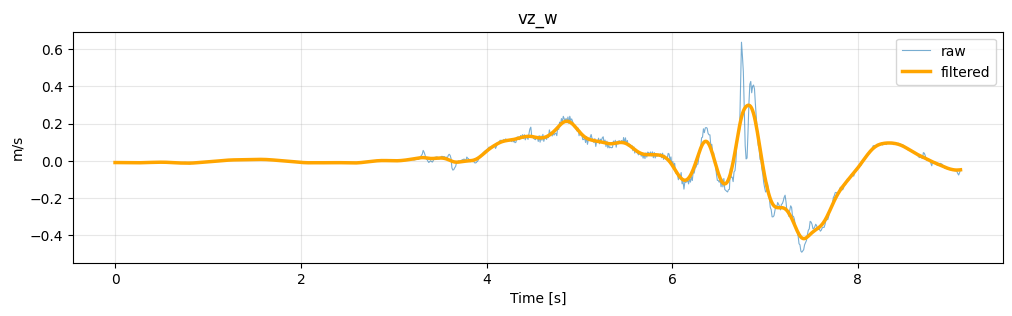

In [394]:
# ------------------------------------------------------------
# DIAGNOSTIC PLOTS: Velocities (raw vs filtered)
# ------------------------------------------------------------

plot_raw_filt(df["vx_w"], df["vx_w_f"], "vx_w", "m/s")
plot_raw_filt(df["vy_w"], df["vy_w_f"], "vy_w", "m/s")
plot_raw_filt(df["vz_w"], df["vz_w_f"], "vz_w", "m/s")

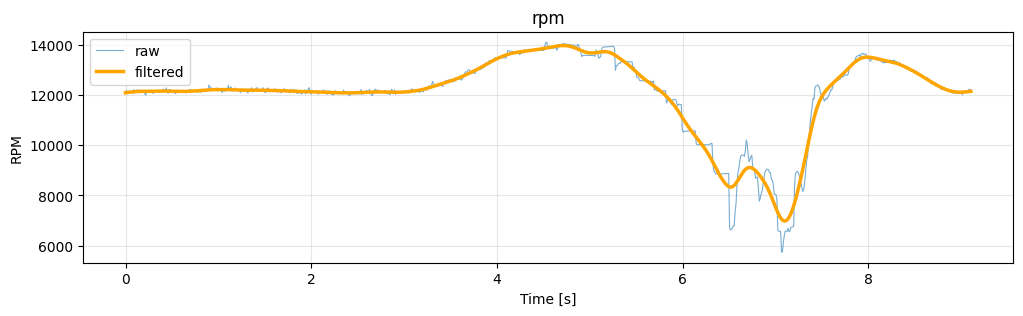

In [395]:
# ------------------------------------------------------------
# DIAGNOSTIC PLOTS: RPM (raw vs filtered)
# ------------------------------------------------------------

plot_raw_filt(df["rpm"], df["rpm_f"], "rpm", "RPM")

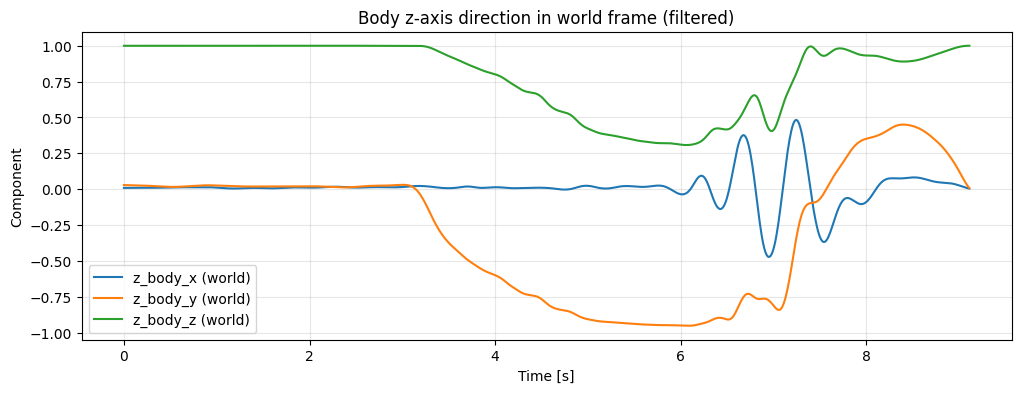

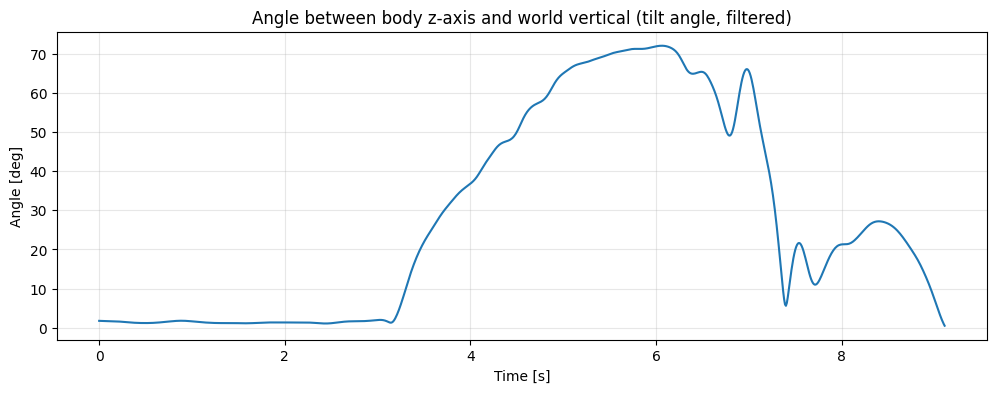

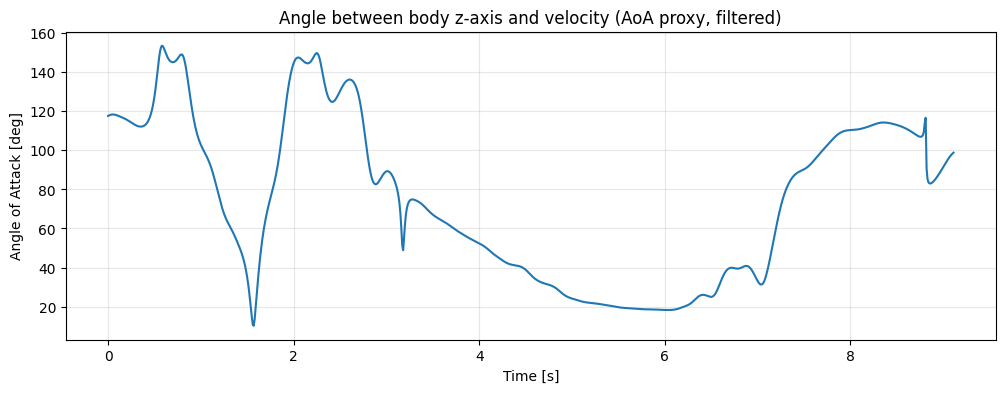

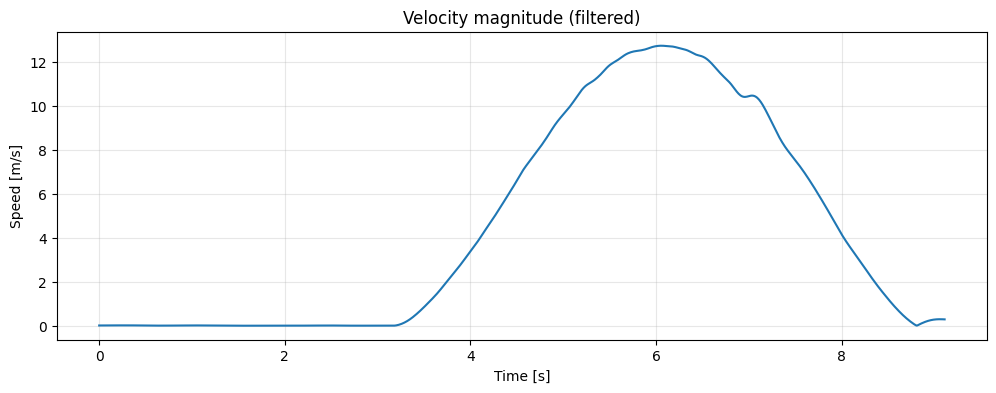

In [396]:
# ------------------------------------------------------------
# BODY Z-AXIS ORIENTATION IN WORLD FRAME (FILTERED)
# ------------------------------------------------------------

# Extract body z-axis direction in world frame using FILTERED quaternions
z_body_in_world = np.zeros((len(df), 3))
for i, row in df.iterrows():
    qw, qx, qy, qz = row["qw_w_f"], row["qx_w_f"], row["qy_w_f"], row["qz_w_f"]
    R_bw = quat2mat([qw, qx, qy, qz])  # body -> world rotation
    # Body z-axis is [0, 0, 1] in body frame
    z_body_in_world[i] = R_bw @ np.array([0, 0, 1])

t_rel = df["t"].to_numpy() - df["t"].min()

# Plot z-axis components in world frame
plt.figure(figsize=(12, 4))
plt.plot(t_rel, z_body_in_world[:, 0], label="z_body_x (world)", linewidth=1.5)
plt.plot(t_rel, z_body_in_world[:, 1], label="z_body_y (world)", linewidth=1.5)
plt.plot(t_rel, z_body_in_world[:, 2], label="z_body_z (world)", linewidth=1.5)
plt.xlabel("Time [s]")
plt.ylabel("Component")
plt.title("Body z-axis direction in world frame (filtered)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Angle from world z-axis (vertical)
world_z = np.array([0, 0, 1])
cos_angle_from_vertical = np.clip(z_body_in_world @ world_z, -1.0, 1.0)
angle_from_vertical_rad = np.arccos(cos_angle_from_vertical)
angle_from_vertical_deg = np.rad2deg(angle_from_vertical_rad)

plt.figure(figsize=(12, 4))
plt.plot(t_rel, angle_from_vertical_deg, linewidth=1.5)
plt.xlabel("Time [s]")
plt.ylabel("Angle [deg]")
plt.title("Angle between body z-axis and world vertical (tilt angle, filtered)")
plt.grid(True, alpha=0.3)
plt.show()

# ------------------------------------------------------------
# ANGLE OF ATTACK (angle between velocity and body z-axis) - FILTERED
# ------------------------------------------------------------

# Compute velocity in body frame for entire dataset using FILTERED quaternions
V_b_full = np.zeros((len(df), 3))
for i, row in df.iterrows():
    qw, qx, qy, qz = row["qw_w_f"], row["qx_w_f"], row["qy_w_f"], row["qz_w_f"]
    Rwb = R_wb(qw, qx, qy, qz)
    v_w = np.array([row["vx_w_f"], row["vy_w_f"], row["vz_w_f"]])
    V_b_full[i] = Rwb @ v_w

# Angle between velocity and body z-axis
V_b_norm = np.linalg.norm(V_b_full, axis=1)
cos_ang = np.clip(V_b_full[:, 2] / (V_b_norm + 1e-12), -1.0, 1.0)
angle_z_rad = np.arccos(cos_ang)
angle_z_deg = np.rad2deg(angle_z_rad)

plt.figure(figsize=(12, 4))
plt.plot(t_rel, angle_z_deg, linewidth=1.5)
plt.xlabel("Time [s]")
plt.ylabel("Angle of Attack [deg]")
plt.title("Angle between body z-axis and velocity (AoA proxy, filtered)")
plt.grid(True, alpha=0.3)
plt.show()

# Also plot velocity magnitude for context
V_mag_full = np.linalg.norm(df[["vx_w_f", "vy_w_f", "vz_w_f"]].to_numpy(), axis=1)
plt.figure(figsize=(12, 4))
plt.plot(t_rel, V_mag_full, linewidth=1.5)
plt.xlabel("Time [s]")
plt.ylabel("Speed [m/s]")
plt.title("Velocity magnitude (filtered)")
plt.grid(True, alpha=0.3)
plt.show()

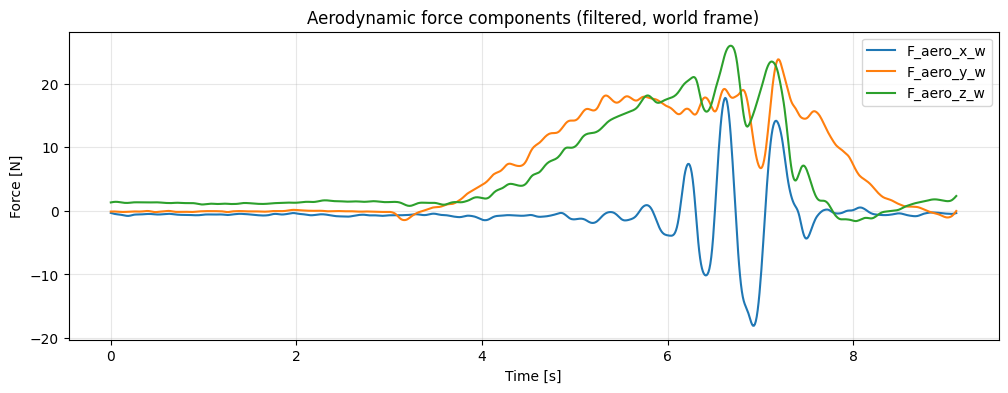

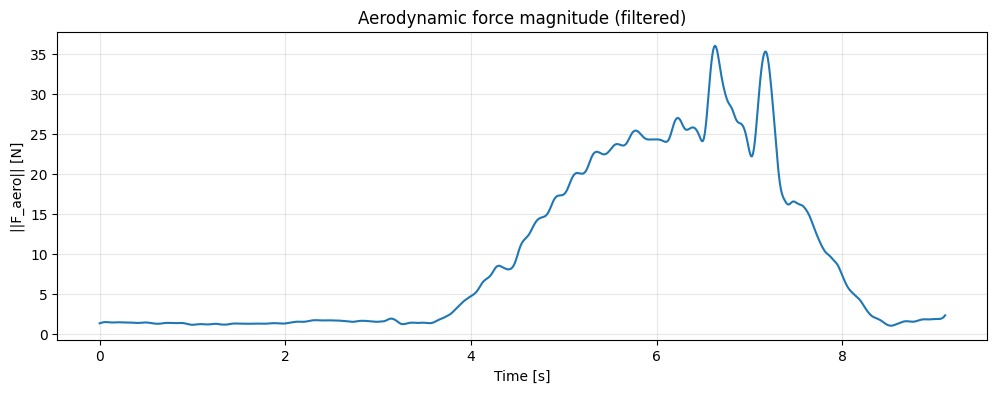

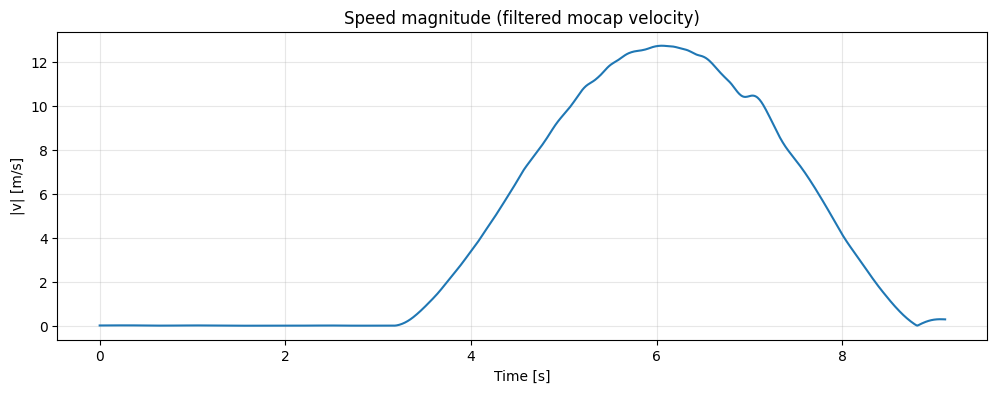

Window 3.30–6.00 s, samples: 271 / 912


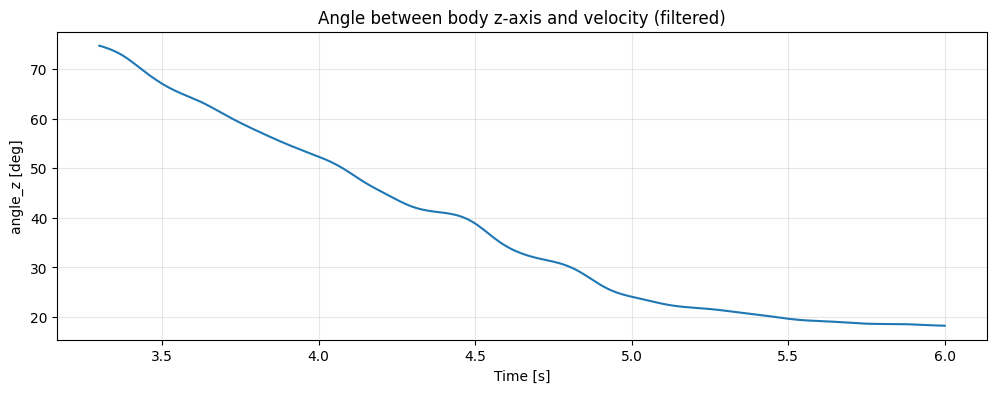

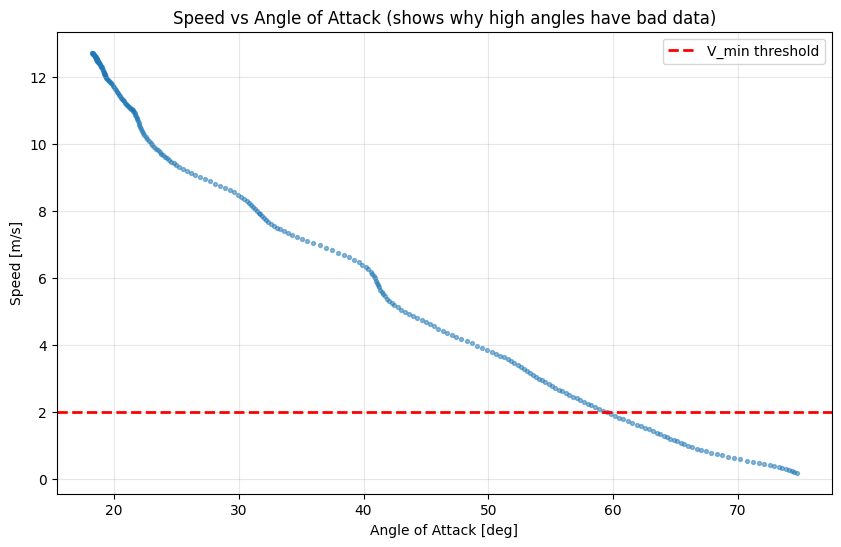

Filtering low speeds: 174 / 271 points kept (V > 5.0 m/s)


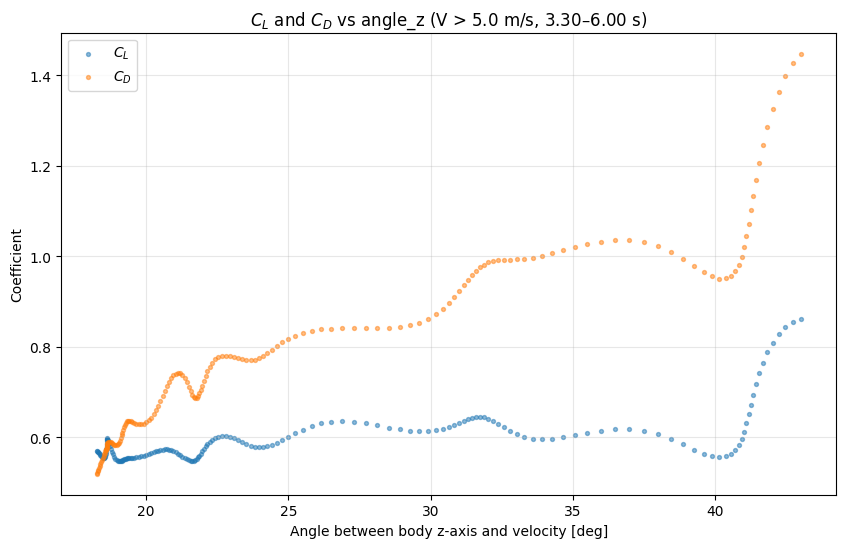

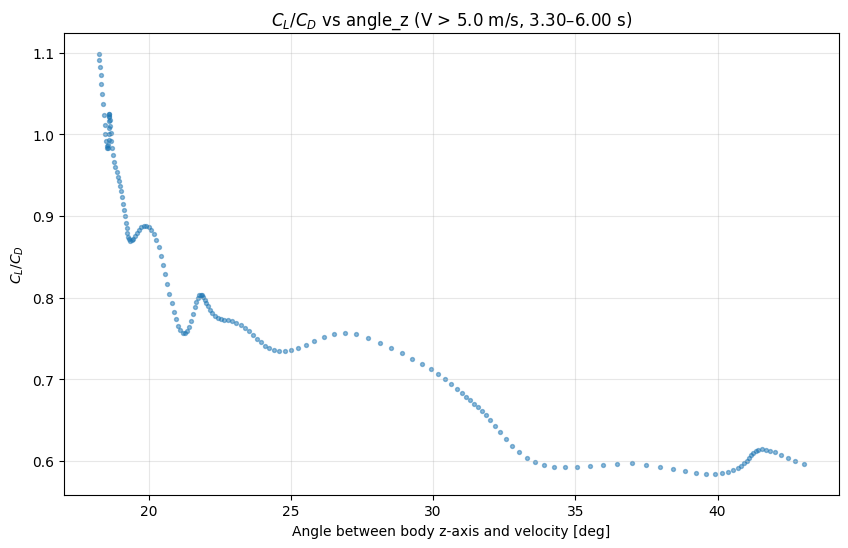

In [397]:
from transforms3d.quaternions import quat2mat
import matplotlib.pyplot as plt
import numpy as np

# ------------------------------------------------------------
# 4. Constants + rotation helper
# ------------------------------------------------------------

mass = 2.5
g = 9.81
g_world = np.array([0.0, 0.0, -g])

def R_wb(qw, qx, qy, qz):
    """world -> body rotation"""
    R_bw = quat2mat([qw, qx, qy, qz])  # body -> world
    return R_bw.T


# ------------------------------------------------------------
# 5. Thrust + aerodynamic force in body frame (FILTERED)
# ------------------------------------------------------------

def thrust_per_motor(rpm_val):
    # your thrust stand mapping
    return 5.15e-8 * rpm_val**2 - 0.09e-3 * rpm_val - 1.0

rpm_f = df["rpm_f"].to_numpy()
T_total_f = 4.0 * thrust_per_motor(rpm_f)

F_thrust_b = np.zeros((len(df), 3))
F_thrust_b[:, 2] = T_total_f

f_b_f = df[["ax_b_f", "ay_b_f", "az_b_f"]].to_numpy()
F_sum_b = mass * f_b_f

F_aero_b = F_sum_b - F_thrust_b  # residual aero in body frame

# ------------------------------------------------------------
# 6. Rotate forces to world frame (FILTERED)
# ------------------------------------------------------------

F_thrust_w = np.zeros_like(F_thrust_b)
F_aero_w   = np.zeros_like(F_thrust_b)
F_g_w      = np.zeros_like(F_thrust_b)
F_g_w[:]   = mass * g_world

for i, row in df.iterrows():
    qw, qx, qy, qz = row["qw_w_f"], row["qx_w_f"], row["qy_w_f"], row["qz_w_f"]
    Rwb = R_wb(qw, qx, qy, qz)
    Rbw = Rwb.T

    F_thrust_w[i] = Rbw @ F_thrust_b[i]
    F_aero_w[i]   = Rbw @ F_aero_b[i]

# ------------------------------------------------------------
# 7. Diagnostics: F_aero and speed vs time (FILTERED)
# ------------------------------------------------------------

t = df["t"].to_numpy()
t_rel = t - t.min()

Fx, Fy, Fz = F_aero_w[:, 0], F_aero_w[:, 1], F_aero_w[:, 2]
Fmag = np.linalg.norm(F_aero_w, axis=1)

plt.figure(figsize=(12, 4))
plt.plot(t_rel, Fx, label="F_aero_x_w")
plt.plot(t_rel, Fy, label="F_aero_y_w")
plt.plot(t_rel, Fz, label="F_aero_z_w")
plt.xlabel("Time [s]")
plt.ylabel("Force [N]")
plt.title("Aerodynamic force components (filtered, world frame)")
plt.legend()
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(t_rel, Fmag)
plt.xlabel("Time [s]")
plt.ylabel("||F_aero|| [N]")
plt.title("Aerodynamic force magnitude (filtered)")
plt.show()

V_w_f = df[["vx_w_f", "vy_w_f", "vz_w_f"]].to_numpy()
V_mag = np.linalg.norm(V_w_f, axis=1)

plt.figure(figsize=(12, 4))
plt.plot(t_rel, V_mag)
plt.xlabel("Time [s]")
plt.ylabel("|v| [m/s]")
plt.title("Speed magnitude (filtered mocap velocity)")
plt.show()

# ------------------------------------------------------------
# 8. Choose analysis window
# ------------------------------------------------------------

t_start = 3.3   # adjust
t_end   = 6.0   # adjust

mask = (t_rel >= t_start) & (t_rel <= t_end)
print(f"Window {t_start:.2f}–{t_end:.2f} s, samples: {mask.sum()} / {len(df)}")

df_win     = df.loc[mask].reset_index(drop=True)
V_w_win    = df_win[["vx_w_f", "vy_w_f", "vz_w_f"]].to_numpy()
F_aero_win = F_aero_w[mask, :]

V_mag_win = np.linalg.norm(V_w_win, axis=1)

# ------------------------------------------------------------
# 9. Drag / lift from projection on velocity
# ------------------------------------------------------------

e_v = V_w_win / (V_mag_win[:, None] + 1e-12)  # unit velocity

# drag > 0 when opposing motion
D = -np.einsum("ij,ij->i", F_aero_win, e_v)

# perpendicular component = "lift-like"
F_parallel = (np.einsum("ij,ij->i", F_aero_win, e_v)[:, None]) * e_v
F_perp     = F_aero_win - F_parallel
L          = np.linalg.norm(F_perp, axis=1)

# ------------------------------------------------------------
# 10. AoA proxy: angle between velocity and body z-axis
# ------------------------------------------------------------

V_b_win = np.zeros_like(V_w_win)
for i, row in df_win.iterrows():
    qw, qx, qy, qz = row["qw_w_f"], row["qx_w_f"], row["qy_w_f"], row["qz_w_f"]
    Rwb = R_wb(qw, qx, qy, qz)    # world -> body
    v_w = np.array([row["vx_w_f"], row["vy_w_f"], row["vz_w_f"]])
    V_b_win[i] = Rwb @ v_w        # body-frame velocity

V_b_norm = np.linalg.norm(V_b_win, axis=1)
cos_ang  = np.clip(V_b_win[:, 2] / (V_b_norm + 1e-12), -1.0, 1.0)
angle_z_rad = np.arccos(cos_ang)
angle_z_deg = np.rad2deg(angle_z_rad)

plt.figure(figsize=(12, 4))
plt.plot(t_rel[mask], angle_z_deg)
plt.xlabel("Time [s]")
plt.ylabel("angle_z [deg]")
plt.title("Angle between body z-axis and velocity (filtered)")
plt.show()

# Diagnostic: Speed vs angle to see correlation
plt.figure(figsize=(10, 6))
plt.scatter(angle_z_deg, V_mag_win, s=8, alpha=0.5)
plt.xlabel("Angle of Attack [deg]")
plt.ylabel("Speed [m/s]")
plt.title("Speed vs Angle of Attack (shows why high angles have bad data)")
plt.grid(True, alpha=0.3)
plt.axhline(2.0, color='red', linestyle='--', linewidth=2, label='V_min threshold')
plt.legend()
plt.show()

# ------------------------------------------------------------
# 11. CL, CD, CL/CD vs angle_z
# ------------------------------------------------------------

rho = 1.225    # air density
S   = 0.318    # wing reference area [m^2] (set correctly!)

q_dyn = 0.5 * rho * V_mag_win**2
eps = 1e-12

CL = L / (q_dyn * S + eps)
CD = D / (q_dyn * S + eps)
CL_CD = CL / (CD + eps)

# Filter out low-speed data to avoid numerical issues
V_min = 5.0  # minimum velocity threshold [m/s]
valid_speed = V_mag_win > V_min
print(f"Filtering low speeds: {valid_speed.sum()} / {len(valid_speed)} points kept (V > {V_min} m/s)")

# Apply mask to all relevant arrays
CL = CL[valid_speed]
CD = CD[valid_speed]
CL_CD = CL_CD[valid_speed]
angle_z_deg_filt = angle_z_deg[valid_speed]
t_rel_filt = t_rel[mask][valid_speed]
V_mag_filt = V_mag_win[valid_speed]

plt.figure(figsize=(10, 6))
plt.scatter(angle_z_deg_filt, CL, s=8, alpha=0.5, label=r"$C_L$")
plt.scatter(angle_z_deg_filt, CD, s=8, alpha=0.5, label=r"$C_D$")
plt.xlabel("Angle between body z-axis and velocity [deg]")
plt.ylabel("Coefficient")
plt.title(f"$C_L$ and $C_D$ vs angle_z (V > {V_min} m/s, {t_start:.2f}–{t_end:.2f} s)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

plt.figure(figsize=(10, 6))
plt.scatter(angle_z_deg_filt, CL_CD, s=8, alpha=0.5)
plt.xlabel("Angle between body z-axis and velocity [deg]")
plt.ylabel(r"$C_L/C_D$")
plt.title(f"$C_L/C_D$ vs angle_z (V > {V_min} m/s, {t_start:.2f}–{t_end:.2f} s)")
plt.grid(True, alpha=0.3)
plt.show()


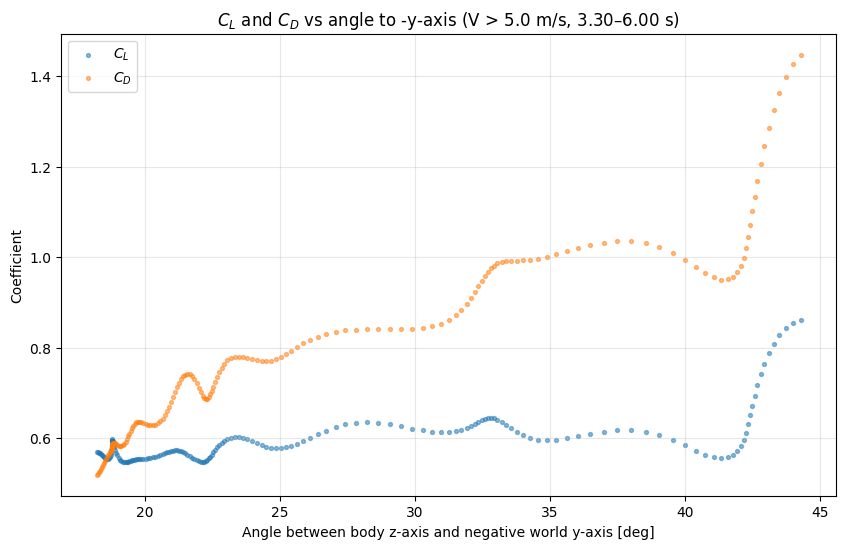

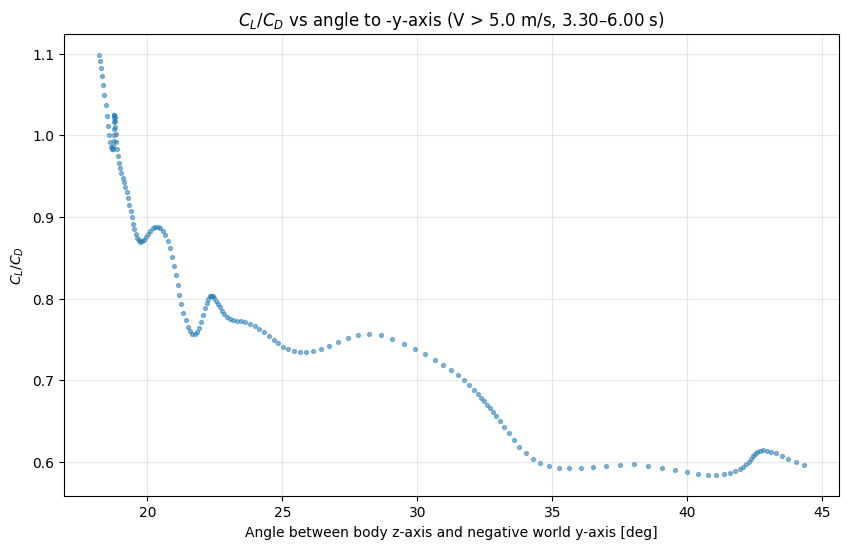

In [398]:
# ------------------------------------------------------------
# 12. CL, CD vs angle between body z-axis and negative world y-axis
# ------------------------------------------------------------

# Compute body z-axis direction in world frame for the analysis window
z_body_in_world_win = np.zeros((len(df_win), 3))
for i, row in df_win.iterrows():
    qw, qx, qy, qz = row["qw_w_f"], row["qx_w_f"], row["qy_w_f"], row["qz_w_f"]
    R_bw = quat2mat([qw, qx, qy, qz])  # body -> world rotation
    # Body z-axis is [0, 0, 1] in body frame
    z_body_in_world_win[i] = R_bw @ np.array([0, 0, 1])

# Negative world y-axis
world_neg_y = np.array([0, -1, 0])

# Compute angle between body z-axis and negative world y-axis
cos_angle_y = np.clip(z_body_in_world_win @ world_neg_y, -1.0, 1.0)
angle_y_rad = np.arccos(cos_angle_y)
angle_y_deg = np.rad2deg(angle_y_rad)

# Filter by minimum velocity (using same threshold as before)
angle_y_deg_filt = angle_y_deg[valid_speed]

# Plot CL and CD vs angle to negative world y-axis
plt.figure(figsize=(10, 6))
plt.scatter(angle_y_deg_filt, CL, s=8, alpha=0.5, label=r"$C_L$")
plt.scatter(angle_y_deg_filt, CD, s=8, alpha=0.5, label=r"$C_D$")
plt.xlabel("Angle between body z-axis and negative world y-axis [deg]")
plt.ylabel("Coefficient")
plt.title(f"$C_L$ and $C_D$ vs angle to -y-axis (V > {V_min} m/s, {t_start:.2f}–{t_end:.2f} s)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

plt.figure(figsize=(10, 6))
plt.scatter(angle_y_deg_filt, CL_CD, s=8, alpha=0.5)
plt.xlabel("Angle between body z-axis and negative world y-axis [deg]")
plt.ylabel(r"$C_L/C_D$")
plt.title(f"$C_L/C_D$ vs angle to -y-axis (V > {V_min} m/s, {t_start:.2f}–{t_end:.2f} s)")
plt.grid(True, alpha=0.3)
plt.show()


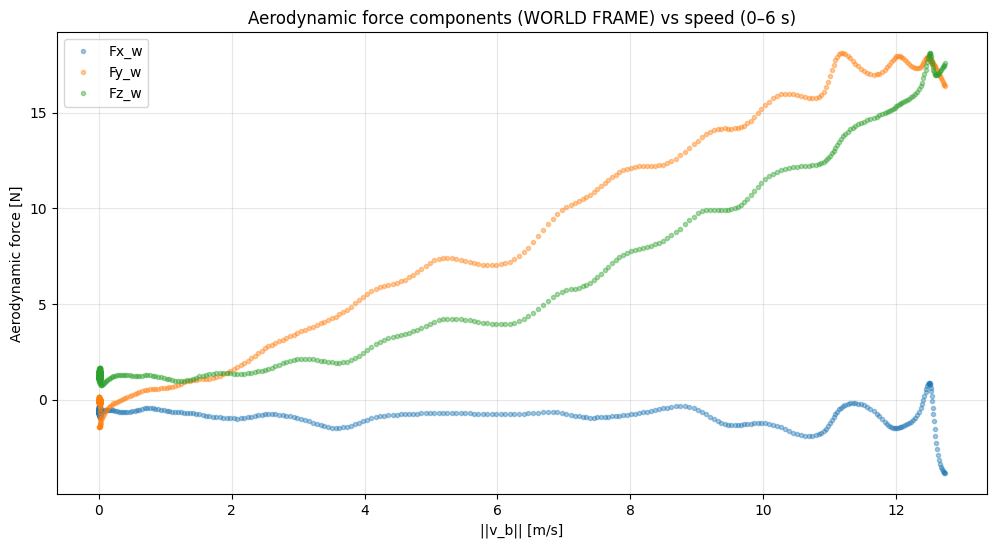

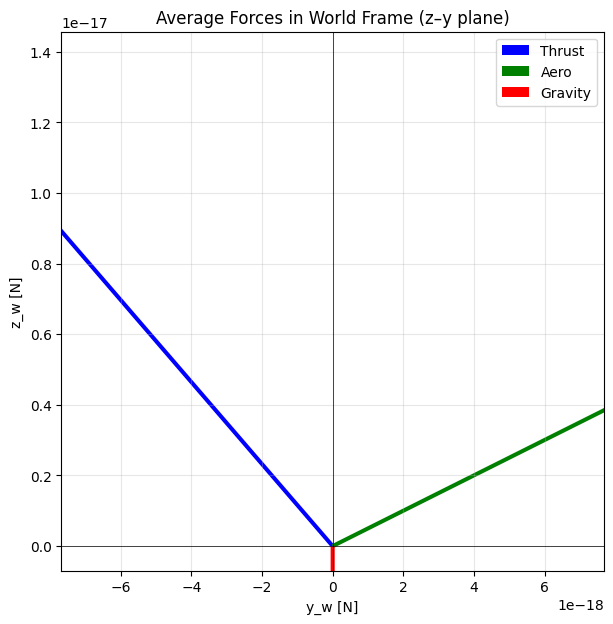

In [399]:
# ------------------------------------------------------------
# ADDITIONAL FORCE ANALYSIS PLOTS
# ------------------------------------------------------------

# Compute body-frame speed magnitude
V_b = []
for _, row in df.iterrows():
    Rwb = R_wb(row["qw_w_f"], row["qx_w_f"], row["qy_w_f"], row["qz_w_f"])
    v_w = np.array([row["vx_w_f"], row["vy_w_f"], row["vz_w_f"]])
    v_b = Rwb @ v_w
    V_b.append(np.linalg.norm(v_b))
V_b = np.array(V_b)

t_rel = df["t"] - df["t"].min()

# PLOT 1: Aerodynamic forces vs speed (0–6 s window)
mask = (t_rel >= 0) & (t_rel <= 6.0)

V_b_win = V_b[mask]
Fx_w = F_aero_w[mask, 0]
Fy_w = F_aero_w[mask, 1]
Fz_w = F_aero_w[mask, 2]

plt.figure(figsize=(12, 6))
plt.plot(V_b_win, Fx_w, ".", alpha=0.4, label="Fx_w")
plt.plot(V_b_win, Fy_w, ".", alpha=0.4, label="Fy_w")
plt.plot(V_b_win, Fz_w, ".", alpha=0.4, label="Fz_w")
plt.xlabel("||v_b|| [m/s]")
plt.ylabel("Aerodynamic force [N]")
plt.legend()
plt.grid(True, alpha=0.3)
plt.title("Aerodynamic force components (WORLD FRAME) vs speed (0–6 s)")
plt.show()

# PLOT 2: Average force vectors in world z–y plane (5.9–6.1 s)
mask_avg = (t_rel >= 4.0) & (t_rel <= 4.25)

Ft_mean = F_thrust_w[mask_avg].mean(axis=0)
Fa_mean = F_aero_w[mask_avg].mean(axis=0)
Fg_mean = F_g_w[mask_avg].mean(axis=0)

y0, z0 = 0.0, 0.0
scale = 1.0

plt.figure(figsize=(7, 7))
plt.quiver(y0, z0, Ft_mean[1]*scale, Ft_mean[2]*scale, color="blue",  label="Thrust", angles="xy", scale_units="xy", scale=1)
plt.quiver(y0, z0, Fa_mean[1]*scale, Fa_mean[2]*scale, color="green", label="Aero",   angles="xy", scale_units="xy", scale=1)
plt.quiver(y0, z0, Fg_mean[1]*scale, Fg_mean[2]*scale, color="red",   label="Gravity",angles="xy", scale_units="xy", scale=1)

plt.axhline(0, color='k', linewidth=0.5)
plt.axvline(0, color='k', linewidth=0.5)
plt.grid(True, alpha=0.3)
plt.xlabel("y_w [N]")
plt.ylabel("z_w [N]")
plt.title("Average Forces in World Frame (z–y plane)")
plt.legend()
plt.axis("equal")
plt.show()

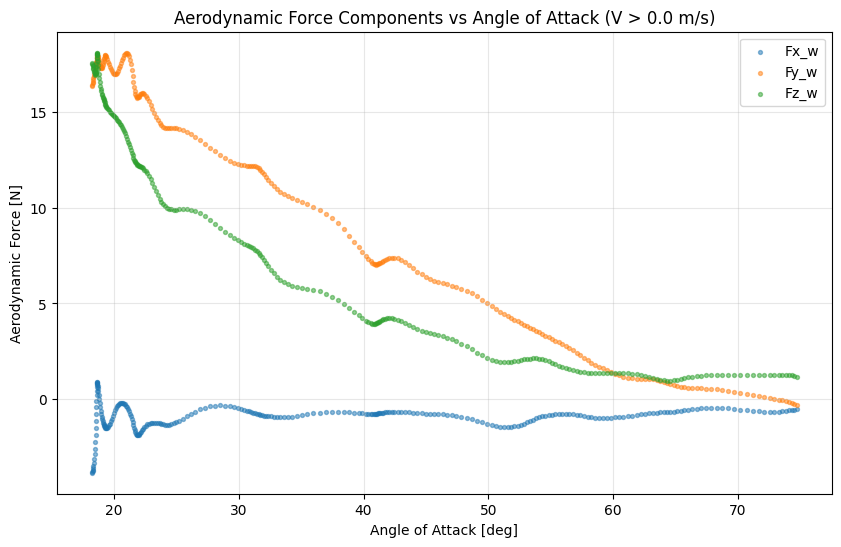

In [400]:
# ------------------------------------------------------------
# PLOT: Aerodynamic forces vs angle of attack
# ------------------------------------------------------------

# Compute angle of attack for the analysis window
V_b_win_aoa = np.zeros_like(V_w_win)
for i, row in df_win.iterrows():
    qw, qx, qy, qz = row["qw_w_f"], row["qx_w_f"], row["qy_w_f"], row["qz_w_f"]
    Rwb = R_wb(qw, qx, qy, qz)
    v_w = np.array([row["vx_w_f"], row["vy_w_f"], row["vz_w_f"]])
    V_b_win_aoa[i] = Rwb @ v_w

V_b_norm_aoa = np.linalg.norm(V_b_win_aoa, axis=1)
cos_ang_aoa = np.clip(V_b_win_aoa[:, 2] / (V_b_norm_aoa + 1e-12), -1.0, 1.0)
angle_z_rad_aoa = np.arccos(cos_ang_aoa)
angle_z_deg_aoa = np.rad2deg(angle_z_rad_aoa)

# Filter by minimum velocity
V_min_plot = 0.0
valid_speed_plot = V_mag_win > V_min_plot

# Extract force components
Fx_win = F_aero_win[:, 0]
Fy_win = F_aero_win[:, 1]
Fz_win = F_aero_win[:, 2]

plt.figure(figsize=(10, 6))
plt.scatter(angle_z_deg_aoa[valid_speed_plot], Fx_win[valid_speed_plot], s=8, alpha=0.5, label="Fx_w")
plt.scatter(angle_z_deg_aoa[valid_speed_plot], Fy_win[valid_speed_plot], s=8, alpha=0.5, label="Fy_w")
plt.scatter(angle_z_deg_aoa[valid_speed_plot], Fz_win[valid_speed_plot], s=8, alpha=0.5, label="Fz_w")
plt.xlabel("Angle of Attack [deg]")
plt.ylabel("Aerodynamic Force [N]")
plt.title(f"Aerodynamic Force Components vs Angle of Attack (V > {V_min_plot} m/s)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [401]:
# ------------------------------------------------------------
# EXPORT DATA TO CSV
# ------------------------------------------------------------

output_dir = Path("/home/nebu/Documents/TUM/Masterarbeit/MasterTheses/data/aero_force_from_imu")
output_dir.mkdir(exist_ok=True)

# 1. Aerodynamic forces vs angle of attack
df_force_vs_alpha = pd.DataFrame({
    'angle_of_attack_deg': angle_z_deg_aoa[valid_speed_plot],
    'Fx_aero_N': Fx_win[valid_speed_plot],
    'Fy_aero_N': Fy_win[valid_speed_plot],
    'Fz_aero_N': Fz_win[valid_speed_plot],
    'velocity_mps': V_mag_win[valid_speed_plot]
})
df_force_vs_alpha.to_csv(output_dir / "aero_force_vs_alpha.csv", index=False)
print(f"Saved: {output_dir / 'aero_force_vs_alpha.csv'}")

# 2. Aerodynamic forces vs velocity (from cell 7)
# Recompute for full analysis window
V_b_full_win = []
for _, row in df.iterrows():
    Rwb = R_wb(row["qw_w_f"], row["qx_w_f"], row["qy_w_f"], row["qz_w_f"])
    v_w = np.array([row["vx_w_f"], row["vy_w_f"], row["vz_w_f"]])
    v_b = Rwb @ v_w
    V_b_full_win.append(np.linalg.norm(v_b))
V_b_full_win = np.array(V_b_full_win)

# Use the mask from cell 7 (0-6s window)
mask_0_6s = (t_rel >= 0) & (t_rel <= 6.0)
df_force_vs_v = pd.DataFrame({
    'velocity_mps': V_b_full_win[mask_0_6s],
    'Fx_aero_N': F_aero_w[mask_0_6s, 0],
    'Fy_aero_N': F_aero_w[mask_0_6s, 1],
    'Fz_aero_N': F_aero_w[mask_0_6s, 2]
})
df_force_vs_v.to_csv(output_dir / "aero_force_vs_velocity.csv", index=False)
print(f"Saved: {output_dir / 'aero_force_vs_velocity.csv'}")

# 3. CL and CD vs angle of attack
df_coeffs = pd.DataFrame({
    'angle_of_attack_deg': angle_z_deg_filt,
    'CL': CL,
    'CD': CD,
    'CL_CD': CL_CD,
    'velocity_mps': V_mag_filt
})
df_coeffs.to_csv(output_dir / "aerodynamic_coefficients.csv", index=False)
print(f"Saved: {output_dir / 'aerodynamic_coefficients.csv'}")

print(f"\nAll data exported to: {output_dir}")

Saved: /home/nebu/Documents/TUM/Masterarbeit/MasterTheses/data/aero_force_from_imu/aero_force_vs_alpha.csv
Saved: /home/nebu/Documents/TUM/Masterarbeit/MasterTheses/data/aero_force_from_imu/aero_force_vs_velocity.csv
Saved: /home/nebu/Documents/TUM/Masterarbeit/MasterTheses/data/aero_force_from_imu/aerodynamic_coefficients.csv

All data exported to: /home/nebu/Documents/TUM/Masterarbeit/MasterTheses/data/aero_force_from_imu


Position data loaded: 2715 samples
Position time range: 0.00 - 9.11 s
Main df time range: -0.00 - 9.11 s
After merging and interpolating: 3626 samples with complete data

Position ranges:
x: [-5.02, -4.69] m
y: [-20.20, 19.98] m
z: [1.53, 1.78] m


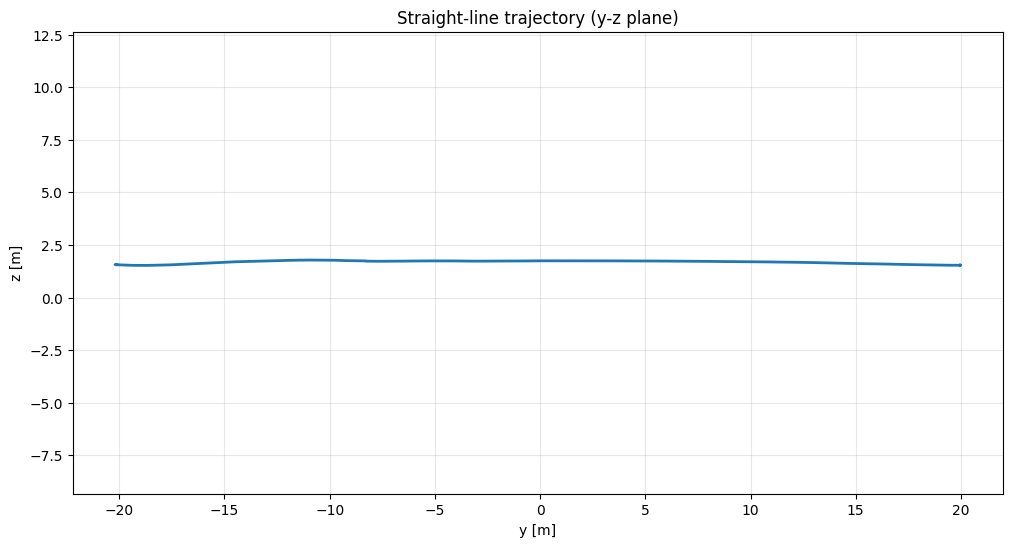

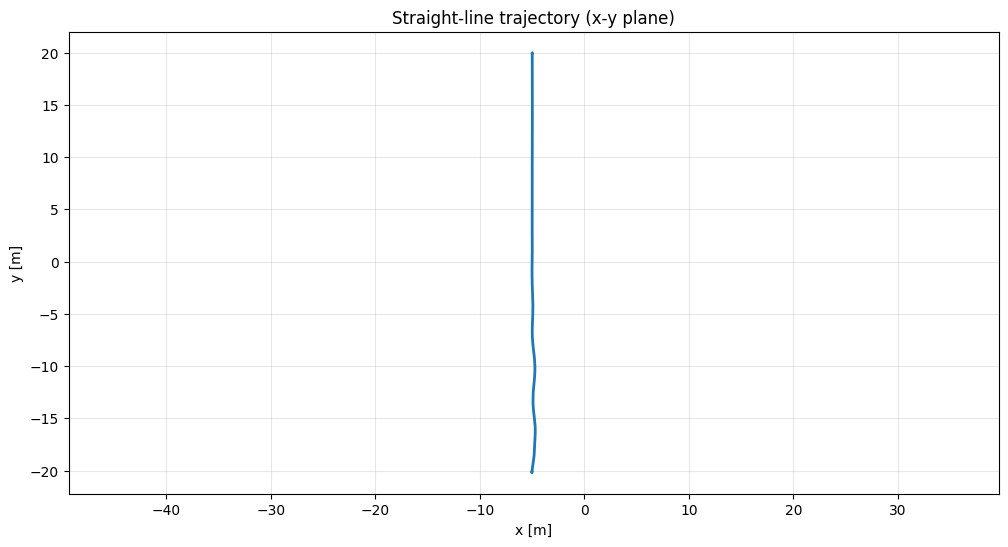

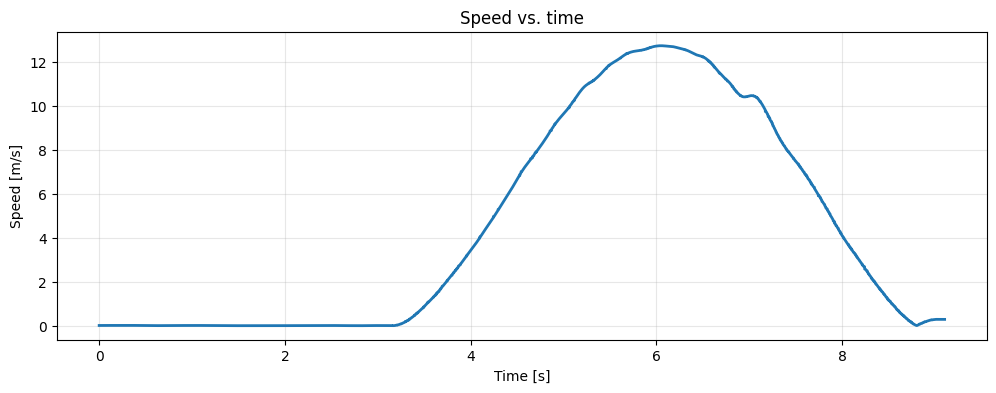

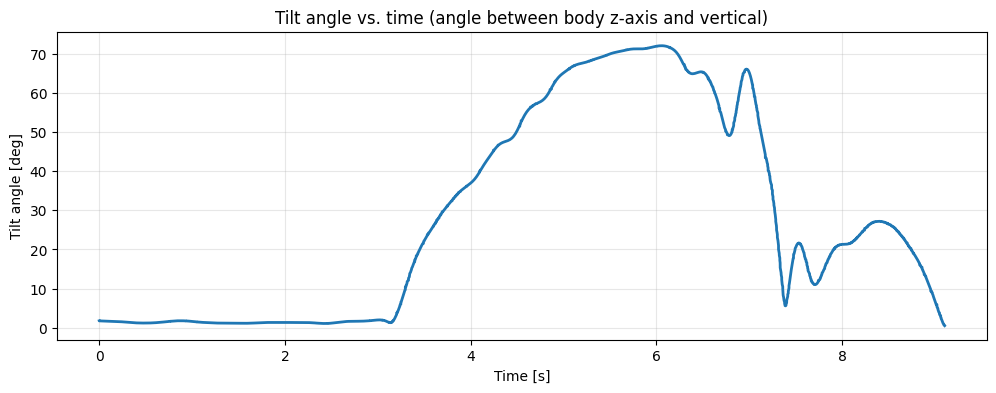


Time range: 0.00 - 9.10 s
Total samples: 3626


In [402]:
# ------------------------------------------------------------
# TRAJECTORY AND KINEMATICS PLOTS FOR THESIS
# ------------------------------------------------------------

# Load position data
px = load_series("pos_x.csv", "px_w")
py = load_series("pos_y.csv", "py_w")
pz = load_series("pos_z.csv", "pz_w")

# Merge position data
df_pos = px.merge(py, on="t", how="outer").merge(pz, on="t", how="outer")
df_pos = df_pos.sort_values("t").reset_index(drop=True)

print(f"Position data loaded: {len(df_pos)} samples")
print(f"Position time range: {df_pos['t'].min():.2f} - {df_pos['t'].max():.2f} s")
print(f"Main df time range: {df['t'].min():.2f} - {df['t'].max():.2f} s")

# Merge with main dataframe using outer join and interpolate
df_with_pos = pd.merge(df, df_pos, on="t", how="outer").sort_values("t")
df_with_pos = df_with_pos.interpolate(method="linear").reset_index(drop=True)

# Keep only rows that have both position and IMU data (no NaN)
df_with_pos = df_with_pos.dropna().reset_index(drop=True)  # Reset index after dropping!
print(f"After merging and interpolating: {len(df_with_pos)} samples with complete data")

# Extract arrays
t_rel = df_with_pos["t"].to_numpy() - df_with_pos["t"].min()
px_arr = df_with_pos["px_w"].to_numpy()
py_arr = df_with_pos["py_w"].to_numpy()
pz_arr = df_with_pos["pz_w"].to_numpy()

print(f"\nPosition ranges:")
print(f"x: [{px_arr.min():.2f}, {px_arr.max():.2f}] m")
print(f"y: [{py_arr.min():.2f}, {py_arr.max():.2f}] m")
print(f"z: [{pz_arr.min():.2f}, {pz_arr.max():.2f}] m")

# Speed
V_mag = np.linalg.norm(df_with_pos[["vx_w_f", "vy_w_f", "vz_w_f"]].to_numpy(), axis=1)

# Tilt angle (angle between body z-axis and world vertical)
z_body_in_world = np.zeros((len(df_with_pos), 3))
for i, row in df_with_pos.iterrows():
    qw, qx, qy, qz = row["qw_w_f"], row["qx_w_f"], row["qy_w_f"], row["qz_w_f"]
    R_bw = quat2mat([qw, qx, qy, qz])
    z_body_in_world[i] = R_bw @ np.array([0, 0, 1])

world_z = np.array([0, 0, 1])
cos_angle_from_vertical = np.clip(z_body_in_world @ world_z, -1.0, 1.0)
tilt_angle_rad = np.arccos(cos_angle_from_vertical)
tilt_angle_deg = np.rad2deg(tilt_angle_rad)

# PLOT 1: Trajectory in y-z plane
plt.figure(figsize=(12, 6))
plt.plot(py_arr, pz_arr, linewidth=2)
plt.xlabel("y [m]")
plt.ylabel("z [m]")
plt.title("Straight-line trajectory (y-z plane)")
plt.grid(True, alpha=0.3)
plt.axis("equal")
plt.show()

# PLOT 2: Trajectory in x-y plane
plt.figure(figsize=(12, 6))
plt.plot(px_arr, py_arr, linewidth=2)
plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.title("Straight-line trajectory (x-y plane)")
plt.grid(True, alpha=0.3)
plt.axis("equal")
plt.show()

# PLOT 3: Speed vs time
plt.figure(figsize=(12, 4))
plt.plot(t_rel, V_mag, linewidth=2)
plt.xlabel("Time [s]")
plt.ylabel("Speed [m/s]")
plt.title("Speed vs. time")
plt.grid(True, alpha=0.3)
plt.show()

# PLOT 4: Tilt angle vs time
plt.figure(figsize=(12, 4))
plt.plot(t_rel, tilt_angle_deg, linewidth=2)
plt.xlabel("Time [s]")
plt.ylabel("Tilt angle [deg]")
plt.title("Tilt angle vs. time (angle between body z-axis and vertical)")
plt.grid(True, alpha=0.3)
plt.show()

print(f"\nTime range: {t_rel.min():.2f} - {t_rel.max():.2f} s")
print(f"Total samples: {len(t_rel)}")


In [403]:
# ------------------------------------------------------------
# EXPORT TRAJECTORY AND KINEMATICS DATA TO CSV
# ------------------------------------------------------------

output_dir = Path("/home/nebu/Documents/TUM/Masterarbeit/MasterTheses/data/aero_force_from_imu")
output_dir.mkdir(exist_ok=True)

# Apply time window: 2.5 to 6.0 seconds for thesis plots
t_start_export = 2.5
t_end_export = 6.0
mask_export = (t_rel >= t_start_export) & (t_rel <= t_end_export)

# 1. Trajectory data (y-z and x-y planes)
df_trajectory = pd.DataFrame({
    'time_s': t_rel[mask_export],
    'x_m': px_arr[mask_export],
    'y_m': py_arr[mask_export],
    'z_m': pz_arr[mask_export]
})
df_trajectory.to_csv(output_dir / "straight_line_trajectory.csv", index=False)
print(f"Saved: {output_dir / 'straight_line_trajectory.csv'}")

# 2. Speed vs time
df_speed = pd.DataFrame({
    'time_s': t_rel[mask_export],
    'speed_mps': V_mag[mask_export]
})
df_speed.to_csv(output_dir / "speed_vs_time.csv", index=False)
print(f"Saved: {output_dir / 'speed_vs_time.csv'}")

# 3. Angle of attack vs time
# Compute angle of attack for the df_with_pos dataset
V_b_with_pos = np.zeros((len(df_with_pos), 3))
for i, row in df_with_pos.iterrows():
    qw, qx, qy, qz = row["qw_w_f"], row["qx_w_f"], row["qy_w_f"], row["qz_w_f"]
    Rwb = R_wb(qw, qx, qy, qz)
    v_w = np.array([row["vx_w_f"], row["vy_w_f"], row["vz_w_f"]])
    V_b_with_pos[i] = Rwb @ v_w

V_b_norm_with_pos = np.linalg.norm(V_b_with_pos, axis=1)
cos_ang_with_pos = np.clip(V_b_with_pos[:, 2] / (V_b_norm_with_pos + 1e-12), -1.0, 1.0)
angle_z_rad_with_pos = np.arccos(cos_ang_with_pos)
angle_z_deg_with_pos = np.rad2deg(angle_z_rad_with_pos)

df_aoa = pd.DataFrame({
    'time_s': t_rel[mask_export],
    'angle_of_attack_deg': angle_z_deg_with_pos[mask_export]
})
df_aoa.to_csv(output_dir / "angle_of_attack_vs_time.csv", index=False)
print(f"Saved: {output_dir / 'angle_of_attack_vs_time.csv'}")

print(f"\nAll trajectory and kinematics data ({t_start_export:.1f}-{t_end_export:.1f} s) exported to: {output_dir}")


Saved: /home/nebu/Documents/TUM/Masterarbeit/MasterTheses/data/aero_force_from_imu/straight_line_trajectory.csv
Saved: /home/nebu/Documents/TUM/Masterarbeit/MasterTheses/data/aero_force_from_imu/speed_vs_time.csv
Saved: /home/nebu/Documents/TUM/Masterarbeit/MasterTheses/data/aero_force_from_imu/angle_of_attack_vs_time.csv

All trajectory and kinematics data (2.5-6.0 s) exported to: /home/nebu/Documents/TUM/Masterarbeit/MasterTheses/data/aero_force_from_imu


In [404]:
# Debug: Check for NaN in raw signals
print("=== NaN CHECK IN RAW SIGNALS ===")
print(f"ax_b has NaN: {df['ax_b'].isna().sum()} / {len(df)}")
print(f"vx_w has NaN: {df['vx_w'].isna().sum()} / {len(df)}")
print(f"rpm has NaN:  {df['rpm'].isna().sum()} / {len(df)}")

print("\n=== MANUALLY TEST FILTER ON ax_b ===")
try:
    test_signal = df['ax_b'].to_numpy()
    print(f"Signal shape: {test_signal.shape}")
    print(f"Signal has NaN: {np.isnan(test_signal).any()}")
    print(f"Signal range: [{test_signal.min():.3f}, {test_signal.max():.3f}]")
    
    # Try filtering
    fs_test = 100.0
    fc_test = 10.0
    nyq = 0.5 * fs_test
    wn = fc_test / nyq
    print(f"Filter params: fc={fc_test}, nyq={nyq}, wn={wn}")
    
    b, a = butter(2, wn, btype="low")
    result = filtfilt(b, a, test_signal)
    print(f"Filter result has NaN: {np.isnan(result).any()}")
    print(f"First 5 results: {result[:5]}")
except Exception as e:
    print(f"ERROR: {e}")

=== NaN CHECK IN RAW SIGNALS ===
ax_b has NaN: 0 / 912
vx_w has NaN: 0 / 912
rpm has NaN:  0 / 912

=== MANUALLY TEST FILTER ON ax_b ===
Signal shape: (912,)
Signal has NaN: False
Signal range: [-13.979, 0.783]
Filter params: fc=10.0, nyq=50.0, wn=0.2
Filter result has NaN: False
First 5 results: [0.06887905 0.0611511  0.05211504 0.0449898  0.04402941]
